--- WEEK 1 METRICS ---
Nodes: 126
Edges: 281
Average Degree: 4.46
Density: 0.0357



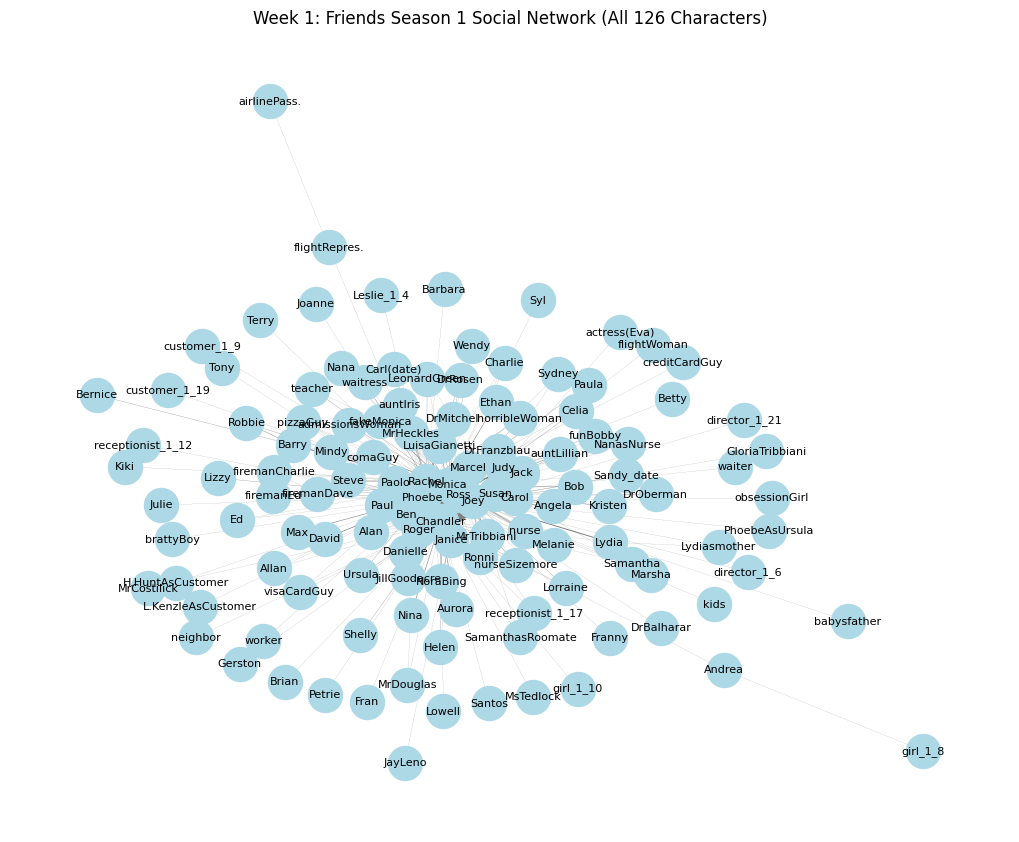

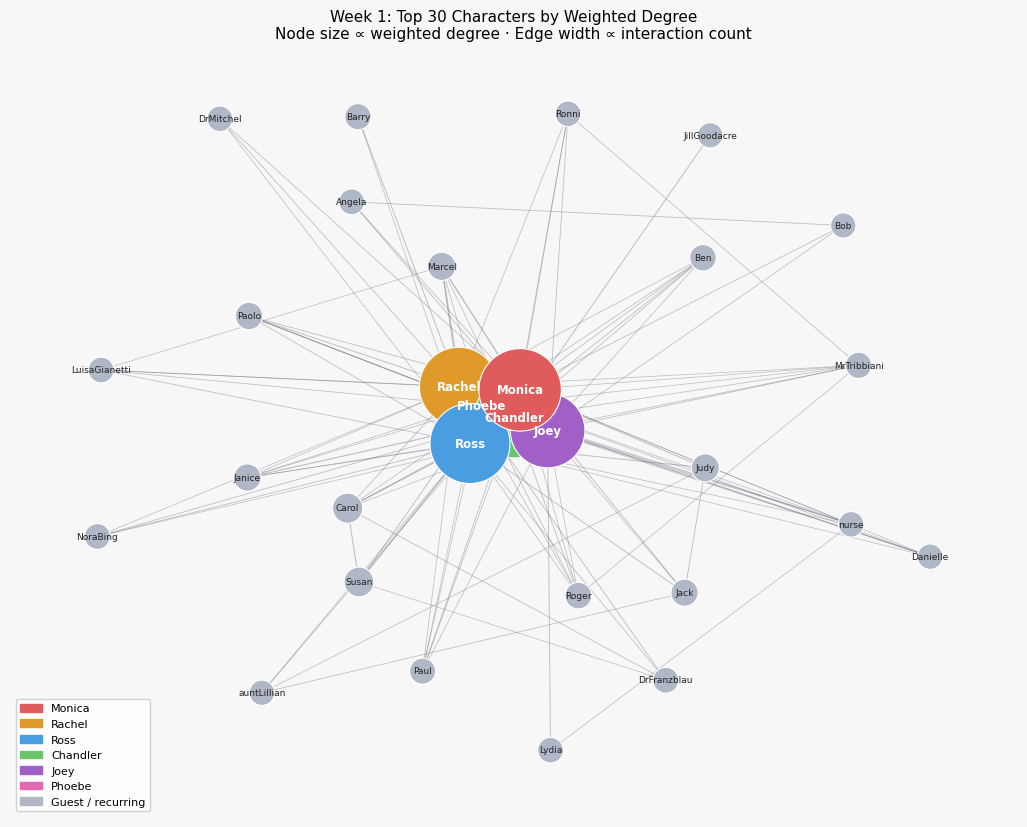

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

G = nx.Graph()

with open('friends_episodes.txt', 'r') as file:
    for line in file:
        if '#s2e1' in line:
            break
        if ']' in line:
            line = line.split(']')[-1]
        line = line.strip()
        if not line or line.startswith('#'):
            continue
        nodes = line.split()
        if len(nodes) >= 2:
            u, v = nodes[0], nodes[1]
            if G.has_edge(u, v):
                G[u][v]['weight'] += 1
            else:
                G.add_edge(u, v, weight=1)

print('--- WEEK 1 METRICS ---')
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
avg_degree = (2 * num_edges) / num_nodes
density = nx.density(G)

print(f'Nodes: {num_nodes}')
print(f'Edges: {num_edges}')
print(f'Average Degree: {avg_degree:.2f}')
print(f'Density: {density:.4f}\n')

# Our group decided to produce two visualisations to show the network at two different levels:
# (1) the FULL graph with all 126 characters shows the real density / structure of the network,
#     including the many peripheral guest characters;
# (2) a FOCUSED graph restricted to the top-30 nodes by weighted degree gives a readable
#     picture of the core characters and their relative importance.

# --- Graph 1: All 126 characters ---
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42)
weights = [G[u][v]['weight'] * 0.1 for u, v in G.edges()]
nx.draw(G, pos, with_labels=True, node_color='lightblue',
        node_size=600, font_size=8, width=weights, edge_color='gray')
plt.title('Week 1: Friends Season 1 Social Network (All 126 Characters)')
plt.show()

# --- Graph 2: Top-30 characters by weighted degree (readable) ---
MAIN_CAST = {'Monica', 'Rachel', 'Ross', 'Chandler', 'Joey', 'Phoebe'}
CAST_COLORS = {
    'Monica': '#e05c5c', 'Rachel': '#e09a2a', 'Ross': '#4a9de0',
    'Chandler': '#6ac46a', 'Joey': '#a060c8', 'Phoebe': '#e06ab4'
}

weighted_deg = dict(G.degree(weight='weight'))
top30 = sorted(weighted_deg, key=weighted_deg.get, reverse=True)[:30]
G_viz = G.subgraph(top30).copy()

pos_viz = nx.spring_layout(G_viz, seed=42, k=2.0)
node_colors = [CAST_COLORS.get(n, '#b0b8c8') for n in G_viz.nodes()]
node_sizes  = [300 + weighted_deg[n] * 4 for n in G_viz.nodes()]
edge_w      = [G_viz[u][v]['weight'] for u, v in G_viz.edges()]
max_w       = max(edge_w) if edge_w else 1
edge_widths = [0.5 + 3.5 * (w / max_w) for w in edge_w]

fig, ax = plt.subplots(figsize=(13, 10))
fig.patch.set_facecolor('#f7f7f7')
ax.set_facecolor('#f7f7f7')
nx.draw_networkx_edges(G_viz, pos_viz, width=edge_widths, alpha=0.4,
                       edge_color='#666677', ax=ax)
nx.draw_networkx_nodes(G_viz, pos_viz, node_size=node_sizes, node_color=node_colors,
                       linewidths=0.8, edgecolors='white', ax=ax)
for node, (x, y) in pos_viz.items():
    ax.text(x, y, node, ha='center', va='center', zorder=5,
            fontsize=8.5 if node in MAIN_CAST else 6.5,
            fontweight='bold' if node in MAIN_CAST else 'normal',
            color='white' if node in MAIN_CAST else '#222222')
legend_handles = [mpatches.Patch(color=c, label=n) for n, c in CAST_COLORS.items()]
legend_handles.append(mpatches.Patch(color='#b0b8c8', label='Guest / recurring'))
ax.legend(handles=legend_handles, loc='lower left', fontsize=8, framealpha=0.9)
ax.set_title('Week 1: Top 30 Characters by Weighted Degree\n'
             'Node size ∝ weighted degree · Edge width ∝ interaction count', fontsize=11)
ax.axis('off')
plt.show()


In [2]:
# ==========================================
# WEEK 2: CLUSTERING & TRANSITIVITY
# ==========================================

largest_cc_nodes = max(nx.connected_components(G), key=len)
G_lc = G.subgraph(largest_cc_nodes).copy()

def get_node_clustering(graph, node):
    neighbors = list(graph.neighbors(node))
    k = len(neighbors)
    if k < 2:
        return 0.0
    edges_between_neighbors = sum(1 for i in range(k) for j in range(i + 1, k)
                                  if graph.has_edge(neighbors[i], neighbors[j]))
    return (2.0 * edges_between_neighbors) / (k * (k - 1))

def get_average_clustering(graph):
    clusterings = [get_node_clustering(graph, n) for n in graph.nodes()]
    return sum(clusterings) / len(clusterings)

my_avg_clustering  = get_average_clustering(G_lc)
nx_avg_clustering  = nx.average_clustering(G_lc)
nx_transitivity    = nx.transitivity(G_lc)

print('--- WEEK 2 METRICS (Largest Connected Component) ---')
print(f'Custom Avg Clustering:   {my_avg_clustering:.4f}')
print(f'NetworkX Avg Clustering: {nx_avg_clustering:.4f}')
print(f'NetworkX Transitivity:   {nx_transitivity:.4f}')


--- WEEK 2 METRICS (Largest Connected Component) ---
Custom Avg Clustering:   0.5058
NetworkX Avg Clustering: 0.5058
NetworkX Transitivity:   0.1593


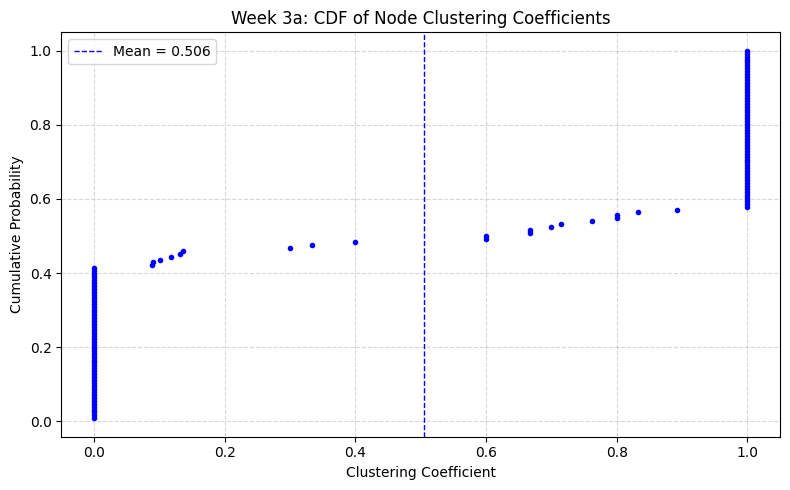

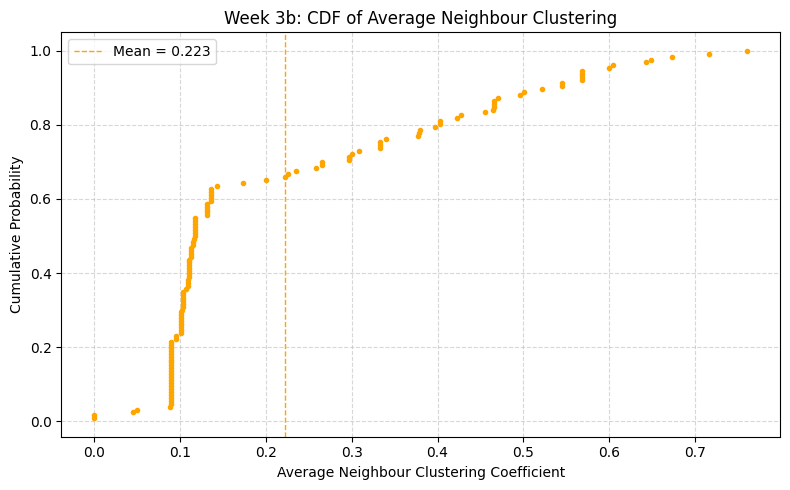

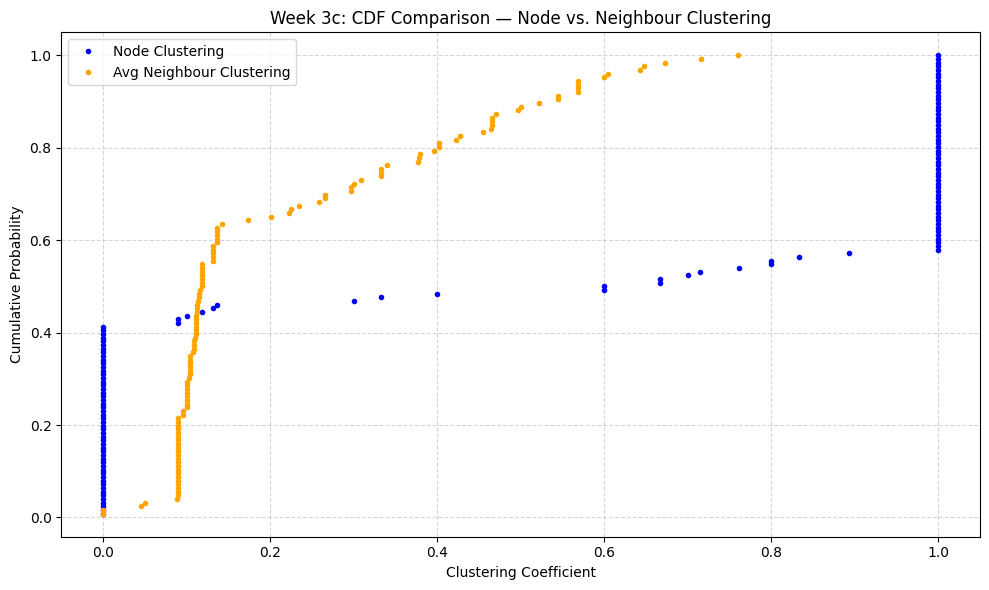

In [3]:
# ==========================================
# WEEK 3: DISTRIBUTIONS
# ==========================================

node_clusterings = [get_node_clustering(G_lc, n) for n in G_lc.nodes()]

def get_avg_neighbor_clustering(graph, node):
    neighbors = list(graph.neighbors(node))
    if not neighbors:
        return 0.0
    return sum(get_node_clustering(graph, nb) for nb in neighbors) / len(neighbors)

neighbor_clusterings = [get_avg_neighbor_clustering(G_lc, n) for n in G_lc.nodes()]

def get_cdf_data(data):
    sorted_data = np.sort(data)
    p = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    return sorted_data, p

x_node, y_node         = get_cdf_data(node_clusterings)
x_neighbor, y_neighbor = get_cdf_data(neighbor_clusterings)

# --- Plot a: CDF of node clustering coefficients ---
plt.figure(figsize=(8, 5))
plt.plot(x_node, y_node, marker='.', linestyle='none', color='blue')
plt.axvline(np.mean(node_clusterings), color='blue', linestyle='--',
            linewidth=1, label=f'Mean = {np.mean(node_clusterings):.3f}')
plt.title('Week 3a: CDF of Node Clustering Coefficients')
plt.xlabel('Clustering Coefficient')
plt.ylabel('Cumulative Probability')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# --- Plot b: CDF of average neighbour clustering ---
plt.figure(figsize=(8, 5))
plt.plot(x_neighbor, y_neighbor, marker='.', linestyle='none', color='orange')
plt.axvline(np.mean(neighbor_clusterings), color='orange', linestyle='--',
            linewidth=1, label=f'Mean = {np.mean(neighbor_clusterings):.3f}')
plt.title('Week 3b: CDF of Average Neighbour Clustering')
plt.xlabel('Average Neighbour Clustering Coefficient')
plt.ylabel('Cumulative Probability')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# --- Plot c: Comparison of both distributions ---
plt.figure(figsize=(10, 6))
plt.plot(x_node, y_node, marker='.', linestyle='none',
         color='blue', label='Node Clustering')
plt.plot(x_neighbor, y_neighbor, marker='.', linestyle='none',
         color='orange', label='Avg Neighbour Clustering')
plt.title('Week 3c: CDF Comparison — Node vs. Neighbour Clustering')
plt.xlabel('Clustering Coefficient')
plt.ylabel('Cumulative Probability')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


**Week 1: The Macroscopic View**

Our group decided to draw **two visualisations** to show the network at different levels:
- **Full graph (126 nodes):** captures the real density of the Season 1 network, including every peripheral guest character.
- **Focused graph (top 30 by weighted degree):** a more readable view that highlights the main cast and the most active recurring characters, with node size proportional to weighted degree and edge width proportional to interaction count.

The network has **126 nodes** and **281 edges**.

**Average Degree (4.46):** On average, a character interacts with about 4.5 other characters. While the main cast (Monica, Chandler, etc.) will have dozens of connections, the many minor guest stars — who only talk to 1 or 2 main characters — pull this average down considerably.

**Density (0.0357):** Only about 3.5% of all possible connections in this network actually exist. This low density perfectly illustrates a core-periphery topology: the core six are tightly knit, but the vast majority of characters on the periphery never meet each other.

---

**Week 2: The Microscopic View**

Our custom average clustering score matches NetworkX's built-in result exactly (0.5058).

**Average Clustering (0.5058):** This is quite high. It means that if you pick a random character, there is roughly a 50% chance their acquaintances also know each other. The value is pulled upward by minor characters: a guest star who only interacts with Ross and Rachel — who already know each other — receives a perfect clustering score of 1.0. Because average clustering gives every node an equal vote, these peripheral characters inflate the overall average.

**Transitivity (0.1593):** This is considerably lower because transitivity counts triangles globally across the entire network, giving more weight to highly connected nodes. The six main characters interact with almost everyone, which creates a large number of potential triangles. However, the guest stars they both know rarely interact with each other, leaving most of those triangles open and pulling the transitivity score down.

---

**Week 3: The Friendship Paradox**

**Plot a — Node Clustering CDF:** The distribution is strongly bimodal. About 40% of the network has a clustering of 0.0 (they only know one person, or their friends don't interact). Another large cluster sits at exactly 1.0: these are one-off guest stars whose only connections are main cast members who already know each other.

**Plot b — Neighbour Clustering CDF:** This distribution is much more concentrated, with most values falling between 0.1 and 0.4. The extreme values visible in the node clustering distribution disappear here because averaging over multiple neighbours smooths out individual outliers.

**Plot c — Comparison:** The gap between the two curves illustrates the Friendship Paradox. Nodes with a clustering of 1.0 (right end of the blue curve) are minor characters whose neighbours are exclusively main cast members. Those main cast members have very low clustering scores because they are connected to dozens of disconnected guest stars — which is precisely why they appear at the left end of the orange curve.
